In [29]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kruskal, f_oneway
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier


In [30]:
#Data and data head
df = pd.read_csv("streaming_platform_shifts_2026.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData Head:")
df.head()


Shape: (81, 10)

Columns:
['movie_id', 'title', 'release_date', 'popularity', 'vote_average', 'vote_count', 'streaming_platforms', 'on_netflix', 'on_hulu', 'on_prime']

Data Head:


,movie_id,title,release_date,popularity,vote_average,vote_count,streaming_platforms,on_netflix,on_hulu,on_prime
0,1317672,Love Me Love Me,2026-02-12,172.5990,5.922,103,"Amazon Prime Video, Amazon Prime Video with Ads",0,0,1
1,1242898,Predator: Badlands,2025-11-05,163.0384,7.723,2041,"Disney Plus, Hulu",0,1,0
2,1243460,Joe's College Road Trip,2026-02-12,66.1207,5.500,39,"Netflix, Netflix Standard with Ads",1,0,0
3,1426964,State of Fear,2026-02-10,168.5810,4.806,31,"Netflix, Netflix Standard with Ads",1,0,0
4,1208348,Rental Family,2025-11-20,21.4637,7.839,388,Hulu,0,1,0


In [31]:
# Data cleaning and feature changing

# release_date to datetime
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")

#create release year column
df["release_year"] = df["release_date"].dt.year

# og transform vote_count because it tends to be skewed
df["log_vote_count"] = np.log1p(df["vote_count"])

# log transform for popularity for the same reasons
df["log_popularity"] = np.log1p(df["popularity"])

# create binary target so high_success = 1 if popularity is above the median
df["high_success"] = (df["popularity"] >= df["popularity"].median()).astype(int)

#check for missing values and successes in data correction
print("\nMissing values:")
print(df.isnull().sum())
print("\nClass balance for high_success:")
print(df["high_success"].value_counts())



Missing values:
movie_id               0
title                  0
release_date           0
popularity             0
vote_average           0
vote_count             0
streaming_platforms    0
on_netflix             0
on_hulu                0
on_prime               0
release_year           0
log_vote_count         0
log_popularity         0
high_success           0
dtype: int64

Class balance for high_success:
high_success
1    41
0    40
Name: count, dtype: int64


C:\Users\jorda\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


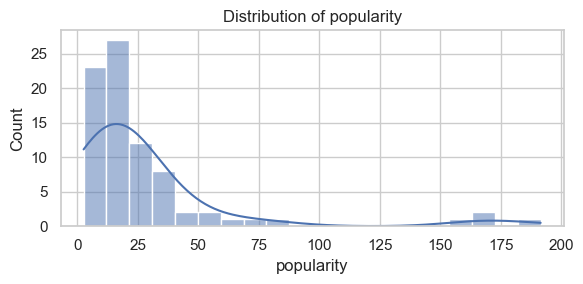

C:\Users\jorda\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


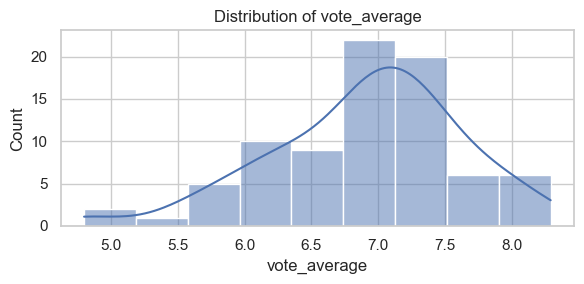

C:\Users\jorda\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


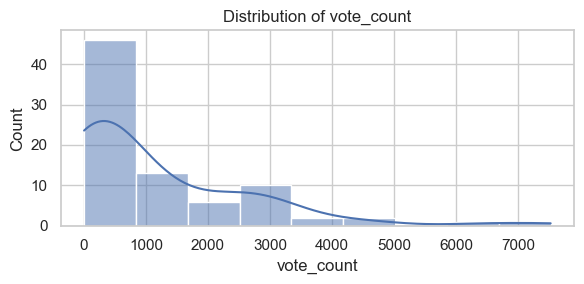

C:\Users\jorda\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


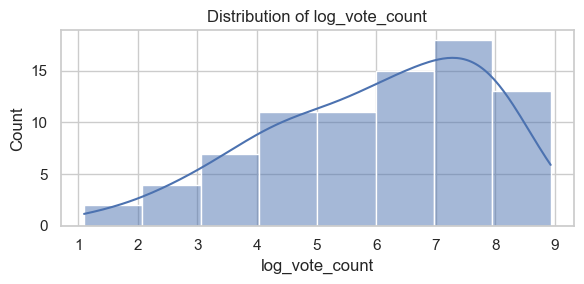

C:\Users\jorda\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


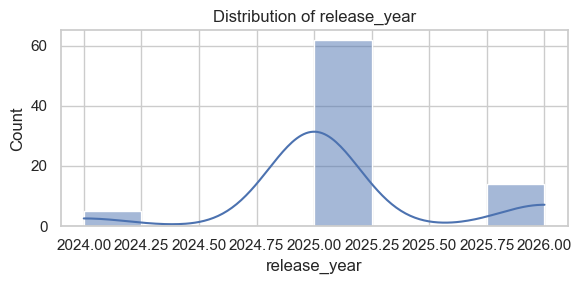

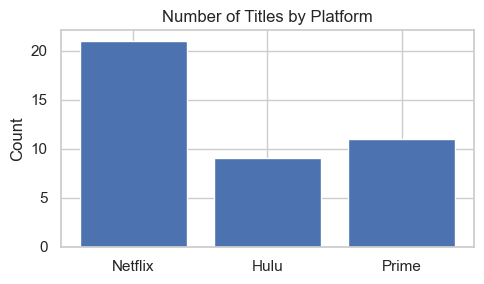

In [32]:
# Basic EDA plots
sns.set_theme(style="whitegrid")

# Histograms
numeric_cols = ["popularity", "vote_average", "vote_count", "log_vote_count", "release_year"]
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

# Platform counts
platform_counts = {
    "Netflix": df["on_netflix"].sum(),
    "Hulu": df["on_hulu"].sum(),
    "Prime": df["on_prime"].sum()
}
plt.figure(figsize=(5, 3))
plt.bar(platform_counts.keys(), platform_counts.values())
plt.title("Number of Titles by Platform")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


C:\Users\jorda\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\jorda\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\jorda\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\jorda\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is 

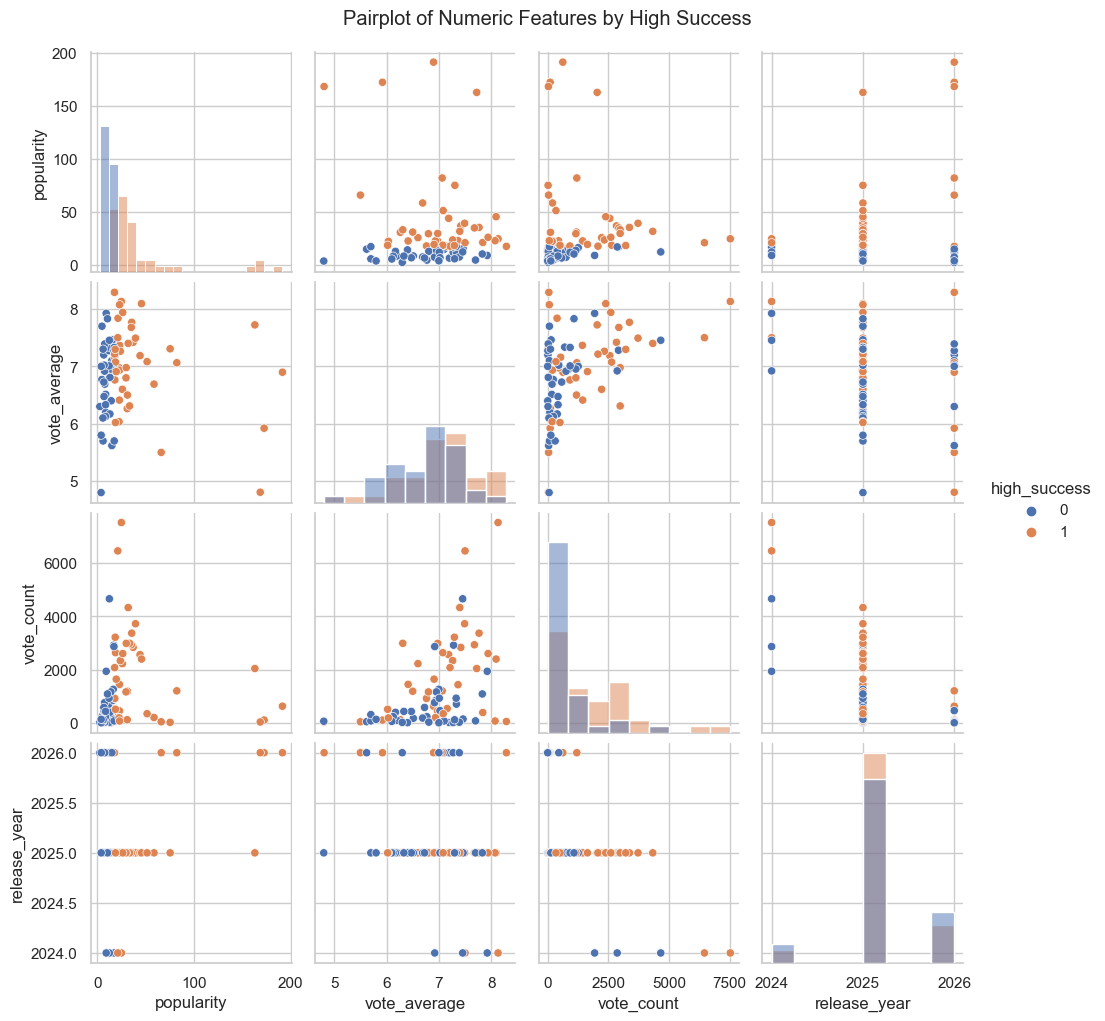

In [33]:
#Pairplot graphs
pairplot_cols = ["popularity", "vote_average", "vote_count", "release_year", "high_success"]
sns.pairplot(df[pairplot_cols].dropna(), hue="high_success", diag_kind="hist")
plt.suptitle("Pairplot of Numeric Features by High Success", y=1.02)
plt.show()

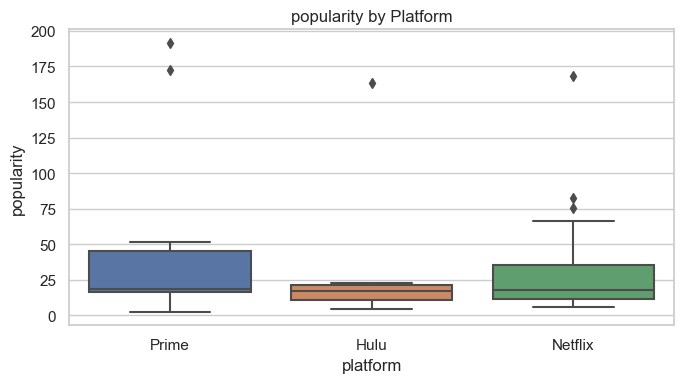

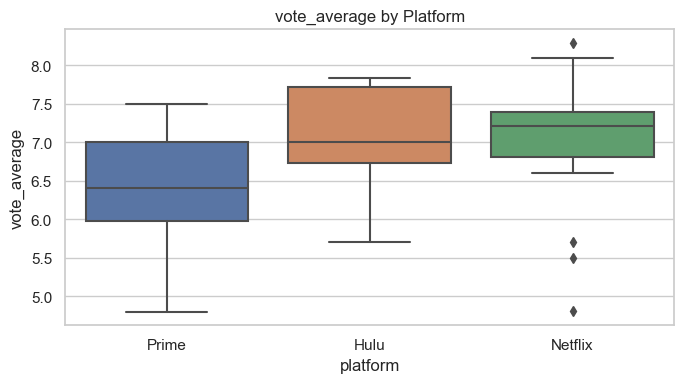

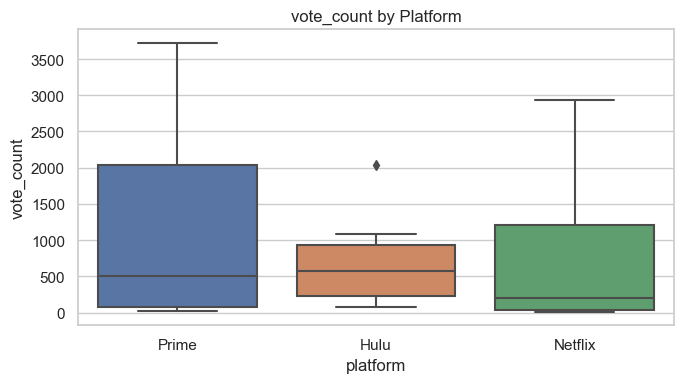

In [35]:
# Boxplots by platform
# function to reshape data for boxplots
def make_platform_long(df, value_col):
    rows = []
    for _, row in df.iterrows():
        if row["on_netflix"] == 1:
            rows.append({"platform": "Netflix", value_col: row[value_col]})
        if row["on_hulu"] == 1:
            rows.append({"platform": "Hulu", value_col: row[value_col]})
        if row["on_prime"] == 1:
            rows.append({"platform": "Prime", value_col: row[value_col]})
    return pd.DataFrame(rows)

for metric in ["popularity", "vote_average", "vote_count"]:
    long_df = make_platform_long(df, metric)

    plt.figure(figsize=(7, 4))
    sns.boxplot(data=long_df, x="platform", y=metric)
    plt.title(f"{metric} by Platform")
    plt.tight_layout()
    plt.show()

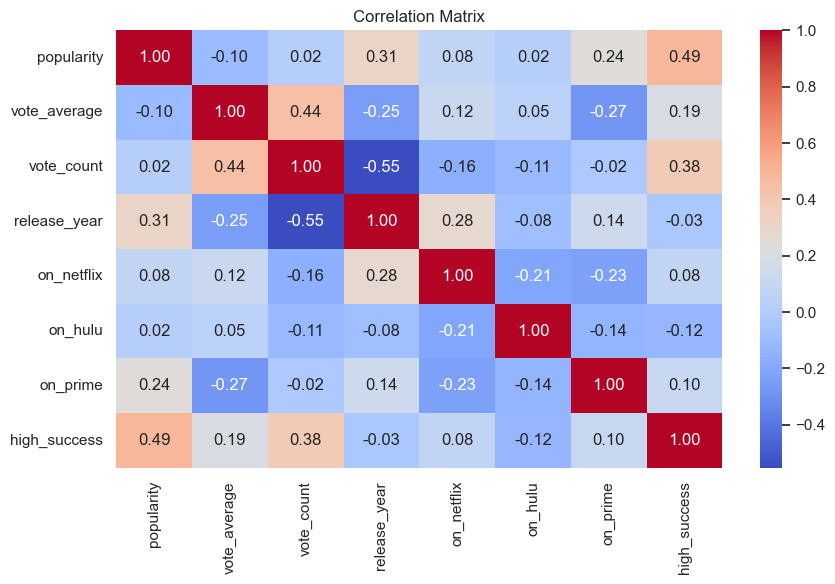

In [36]:
#Correlation matrix
corr_cols = [
    "popularity", "vote_average", "vote_count", "release_year",
    "on_netflix", "on_hulu", "on_prime", "high_success"
]

plt.figure(figsize=(9, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [37]:
# stats tests
# comparing popularity across platforms
netflix_pop = df.loc[df["on_netflix"] == 1, "popularity"]
hulu_pop = df.loc[df["on_hulu"] == 1, "popularity"]
prime_pop = df.loc[df["on_prime"] == 1, "popularity"]

# Kruskal-Wallis test (better for skewed data)
kw_stat, kw_p = kruskal(netflix_pop, hulu_pop, prime_pop)
print("\nKruskal-Wallis test for popularity across platforms")
print("Statistic:", kw_stat)
print("p-value:", kw_p)

# one-way ANOVA
anova_stat, anova_p = f_oneway(netflix_pop, hulu_pop, prime_pop)
print("\nOne-way ANOVA for popularity across platforms")
print("Statistic:", anova_stat)
print("p-value:", anova_p)

# repeat the same for vote_average and vote_count
for metric in ["vote_average", "vote_count"]:
    netflix_vals = df.loc[df["on_netflix"] == 1, metric]
    hulu_vals = df.loc[df["on_hulu"] == 1, metric]
    prime_vals = df.loc[df["on_prime"] == 1, metric]

    kw_stat, kw_p = kruskal(netflix_vals, hulu_vals, prime_vals)
    print(f"\nKruskal-Wallis for {metric}")
    print("Statistic:", kw_stat)
    print("p-value:", kw_p)


Kruskal-Wallis test for popularity across platforms
Statistic: 1.2703641693188672
p-value: 0.529839003979082

One-way ANOVA for popularity across platforms
Statistic: 0.5393858891905585
p-value: 0.5875044064479438

Kruskal-Wallis for vote_average
Statistic: 4.561282432177114
p-value: 0.10221864145958111

Kruskal-Wallis for vote_count
Statistic: 1.2135290184070584
p-value: 0.545111722887688


In [38]:
# prep modeling data
feature_cols = [
    "vote_average",
    "vote_count",
    "release_year",
    "on_netflix",
    "on_hulu",
    "on_prime"
]

X = df[feature_cols].copy()
y = df["high_success"]

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


=== Logistic Regression ===
Accuracy: 0.6190476190476191
F1: 0.6363636363636364
ROC-AUC: 0.6181818181818183
              precision    recall  f1-score   support

           0       0.60      0.60      0.60        10
           1       0.64      0.64      0.64        11

    accuracy                           0.62        21
   macro avg       0.62      0.62      0.62        21
weighted avg       0.62      0.62      0.62        21



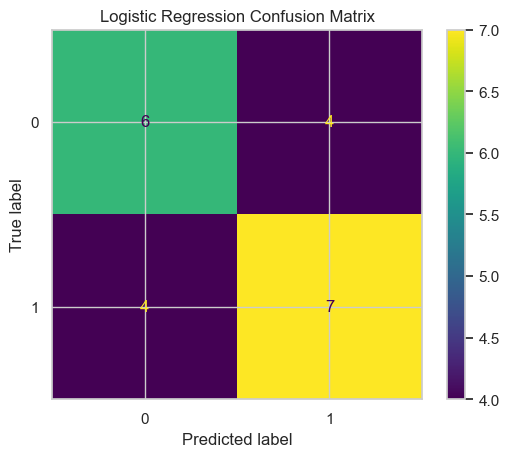

In [39]:
# logistic regression
log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print("\n=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("F1:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))
print(classification_report(y_test, y_pred_log))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log)
plt.title("Logistic Regression Confusion Matrix")
plt.show()


=== Decision Tree ===
Accuracy: 0.5714285714285714
F1: 0.5714285714285714
ROC-AUC: 0.5681818181818181
              precision    recall  f1-score   support

           0       0.55      0.60      0.57        10
           1       0.60      0.55      0.57        11

    accuracy                           0.57        21
   macro avg       0.57      0.57      0.57        21
weighted avg       0.57      0.57      0.57        21



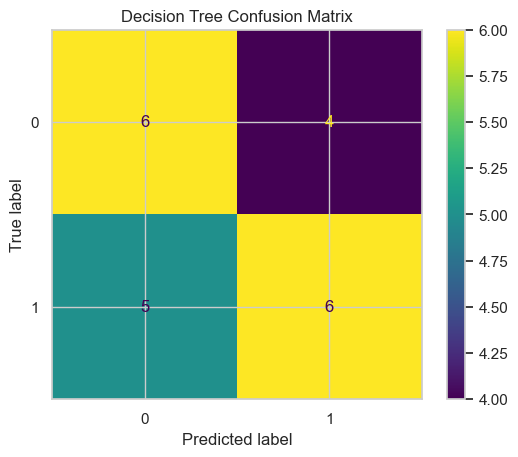

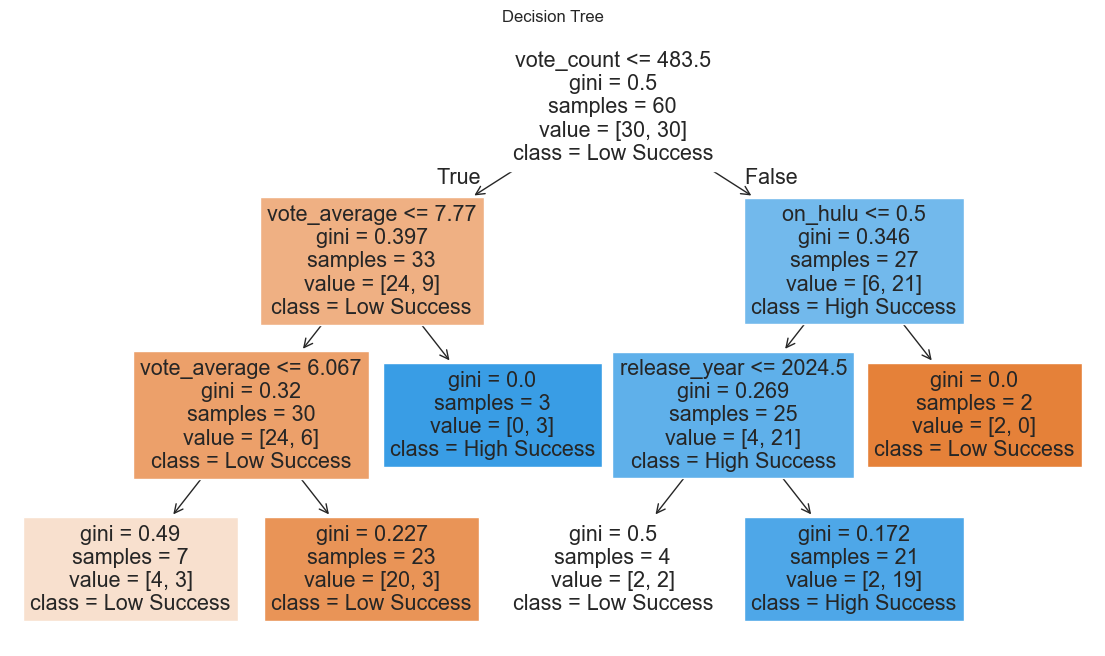

In [40]:
# decision tree
tree_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=5,
    random_state=42
)

tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]

print("\n=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("F1:", f1_score(y_test, y_pred_tree))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_tree))
print(classification_report(y_test, y_pred_tree))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree)
plt.title("Decision Tree Confusion Matrix")
plt.show()

plt.figure(figsize=(14, 8))
plot_tree(
    tree_model,
    feature_names=feature_cols,
    class_names=["Low Success", "High Success"],
    filled=True
)
plt.title("Decision Tree")
plt.show()



=== Random Forest ===
Accuracy: 0.5238095238095238
F1: 0.6153846153846154
ROC-AUC: 0.6090909090909091
              precision    recall  f1-score   support

           0       0.50      0.30      0.38        10
           1       0.53      0.73      0.62        11

    accuracy                           0.52        21
   macro avg       0.52      0.51      0.50        21
weighted avg       0.52      0.52      0.50        21



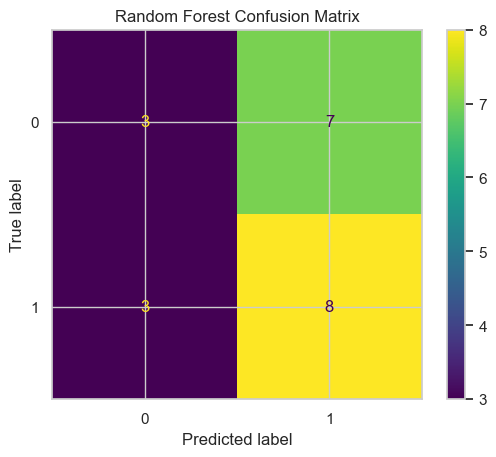

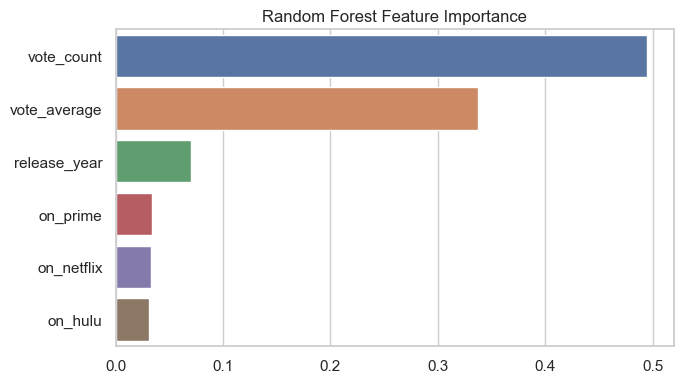

In [41]:
# random forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("\n=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest Confusion Matrix")
plt.show()

# feature importance graph
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()



=== MLP / Feedforward Neural Network ===
Accuracy: 0.5714285714285714
F1: 0.6666666666666666
ROC-AUC: 0.5636363636363636
              precision    recall  f1-score   support

           0       0.60      0.30      0.40        10
           1       0.56      0.82      0.67        11

    accuracy                           0.57        21
   macro avg       0.58      0.56      0.53        21
weighted avg       0.58      0.57      0.54        21



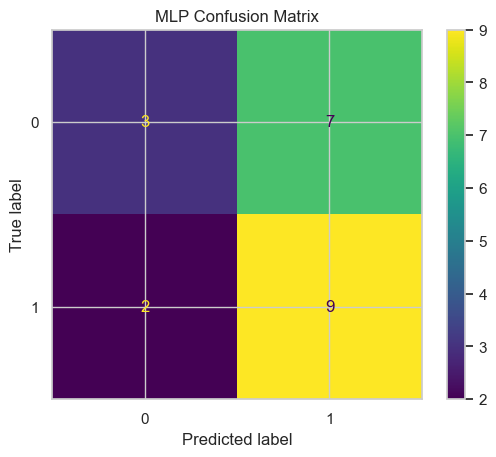

In [42]:
#imports (New test)
from sklearn.neural_network import MLPClassifier

# feedforward neural network/ MLP
mlp_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(16, 8),
        activation="relu",
        solver="adam",
        alpha=0.001,
        max_iter=2000,
        random_state=42
    ))
])

mlp_model.fit(X_train, y_train)
y_pred_mlp = mlp_model.predict(X_test)
y_prob_mlp = mlp_model.predict_proba(X_test)[:, 1]

print("\n=== MLP / Feedforward Neural Network ===")
print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print("F1:", f1_score(y_test, y_pred_mlp))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_mlp))
print(classification_report(y_test, y_pred_mlp))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_mlp)
plt.title("MLP Confusion Matrix")
plt.show()


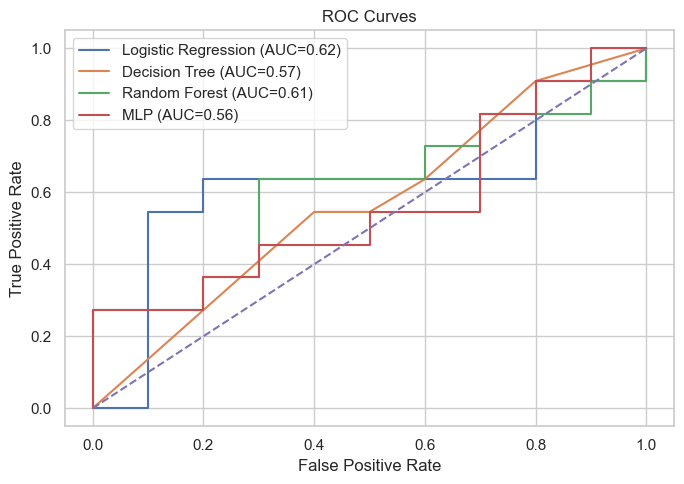

In [46]:
# ROC variables for all models
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_prob_mlp)

# ROC curve plot
plt.figure(figsize=(7, 5))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC={roc_auc_score(y_test, y_prob_log):.2f})")
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree (AUC={roc_auc_score(y_test, y_prob_tree):.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test, y_prob_rf):.2f})")
plt.plot(fpr_mlp, tpr_mlp, label=f"MLP (AUC={roc_auc_score(y_test, y_prob_mlp):.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
# cross-validation comparison
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_cv = cross_val_score(log_model, X, y, cv=cv, scoring="roc_auc")
tree_cv = cross_val_score(tree_model, X, y, cv=cv, scoring="roc_auc")
rf_cv = cross_val_score(rf_model, X, y, cv=cv, scoring="roc_auc")
mlp_cv = cross_val_score(mlp_model, X, y, cv=cv, scoring="roc_auc")

print("\n=== 5-Fold CV ROC-AUC ===")
print("Logistic Regression:", log_cv.mean(), "+/-", log_cv.std())
print("Decision Tree:", tree_cv.mean(), "+/-", tree_cv.std())
print("Random Forest:", rf_cv.mean(), "+/-", rf_cv.std())
print("MLP:", mlp_cv.mean(), "+/-", mlp_cv.std())

C:\Users\jorda\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\jorda\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\jorda\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(



=== 5-Fold CV ROC-AUC ===
Logistic Regression: 0.679861111111111 +/- 0.14405580060612486
Decision Tree: 0.6602430555555555 +/- 0.07434448616714484
Random Forest: 0.6895833333333334 +/- 0.14981904594469214
MLP: 0.5690972222222223 +/- 0.1811135874489873



Platform Summary:
  Platform  Average Predicted Success  Average Popularity  \
2    Prime                   0.601333           50.421273   
0  Netflix                   0.564666           32.985571   
1     Hulu                   0.449840           30.716744   

   Average Vote Average  
2              6.412818  
0              7.044429  
1              6.995778  


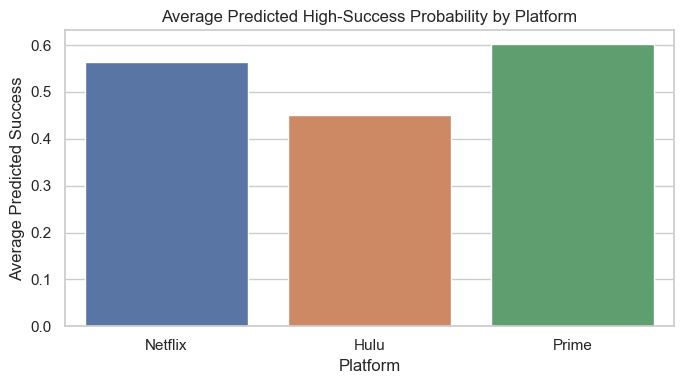

In [45]:
# platform-level predicted strength

# Using best model here starting with random forest
df["predicted_high_success_prob"] = rf_model.predict_proba(X)[:, 1]

platform_summary = pd.DataFrame({
    "Platform": ["Netflix", "Hulu", "Prime"],
    "Average Predicted Success": [
        df.loc[df["on_netflix"] == 1, "predicted_high_success_prob"].mean(),
        df.loc[df["on_hulu"] == 1, "predicted_high_success_prob"].mean(),
        df.loc[df["on_prime"] == 1, "predicted_high_success_prob"].mean()
    ],
    "Average Popularity": [
        df.loc[df["on_netflix"] == 1, "popularity"].mean(),
        df.loc[df["on_hulu"] == 1, "popularity"].mean(),
        df.loc[df["on_prime"] == 1, "popularity"].mean()
    ],
    "Average Vote Average": [
        df.loc[df["on_netflix"] == 1, "vote_average"].mean(),
        df.loc[df["on_hulu"] == 1, "vote_average"].mean(),
        df.loc[df["on_prime"] == 1, "vote_average"].mean()
    ]
})

print("\nPlatform Summary:")
print(platform_summary.sort_values("Average Predicted Success", ascending=False))

plt.figure(figsize=(7, 4))
sns.barplot(data=platform_summary, x="Platform", y="Average Predicted Success")
plt.title("Average Predicted High-Success Probability by Platform")
plt.tight_layout()
plt.show()